In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

In [2]:
# Load the final Random Forest model and its scaler

final_model = joblib.load(
    "../models/final_random_forest.pkl"
)

final_scaler = joblib.load(
    "../models/final_random_forest_scaler.pkl"
)

print(final_model)

print(final_scaler)

RandomForestClassifier(class_weight='balanced', max_features='log2',
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)
StandardScaler()


In [3]:
# Load the cleaned SWaT dataset

df = pd.read_csv(
    "../data/processed/SWaT_cleaned.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (946733, 46)
                 Timestamp    FIT101    LIT101  P101  P102    AIT202  \
0   28/12/2015 10:00:00 AM  2.427057  522.8467     2     1  8.396437   
1   28/12/2015 10:00:01 AM  2.446274  522.8860     2     1  8.396437   
2   28/12/2015 10:00:02 AM  2.489191  522.8467     2     1  8.394514   
3   28/12/2015 10:00:03 AM  2.534350  522.9645     2     1  8.394514   
4   28/12/2015 10:00:04 AM  2.569260  523.4748     2     1  8.394514   

     AIT203    FIT201  P203  P205  ...  P501  P502    PIT501    PIT502  \
0  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
1  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
2  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
3  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
4  328.6337  2.443085     2     2  ...     2     1  250.8812  1.649953   

     PIT503    FIT601  P601  P602  P603  Normal/Attack  
0  189.5988  0.000128     1     1    

In [4]:
# Prepare chronological data for final evaluation

df_time = df.copy()

# Convert Timestamp to datetime
df_time["Timestamp"] = pd.to_datetime(
    df_time["Timestamp"],
    format="mixed",
    dayfirst=True
)

# Sort data chronologically
df_time = df_time.sort_values(
    "Timestamp"
).reset_index(drop=True)

# Use the first 80% for training
# and the last 20% for final testing
split_index = int(len(df_time) * 0.8)

test_time = df_time.iloc[split_index:].copy()

print("Final test set shape:", test_time.shape)

print("\nTest label distribution:")
print(
    test_time["Normal/Attack"].value_counts()
)

Final test set shape: (189347, 46)

Test label distribution:
Normal/Attack
0    179227
1     10120
Name: count, dtype: int64


In [5]:
# Separate features from the target variable

X_final_test = test_time.drop(
    columns=["Timestamp", "Normal/Attack"]
)

y_final_test = test_time["Normal/Attack"]

print("X_final_test shape:", X_final_test.shape)
print("y_final_test shape:", y_final_test.shape)

X_final_test shape: (189347, 44)
y_final_test shape: (189347,)


In [6]:
# Transform the final test features using
# the scaler fitted on the time-based training data

X_final_test_scaled = final_scaler.transform(
    X_final_test
)

print(
    "X_final_test_scaled shape:",
    X_final_test_scaled.shape
)

X_final_test_scaled shape: (189347, 44)


In [7]:
# Generate predictions and probability scores
# using the final Random Forest model

y_final_pred = final_model.predict(
    X_final_test_scaled
)

y_final_proba = final_model.predict_proba(
    X_final_test_scaled
)[:, 1]



In [8]:
# Final classification report


print(
    classification_report(
        y_final_test,
        y_final_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97    179227
      Attack       0.39      0.33      0.36     10120

    accuracy                           0.94    189347
   macro avg       0.68      0.65      0.66    189347
weighted avg       0.93      0.94      0.93    189347



In [9]:
# Calculate final ROC-AUC and PR-AUC

final_roc_auc = roc_auc_score(
    y_final_test,
    y_final_proba
)

final_pr_auc = average_precision_score(
    y_final_test,
    y_final_proba
)

print(f"Final ROC-AUC: {final_roc_auc:.4f}")
print(f"Final PR-AUC: {final_pr_auc:.4f}")

Final ROC-AUC: 0.6407
Final PR-AUC: 0.3772


In [10]:
# Confusion Matrix for the final model

cm = confusion_matrix(
    y_final_test,
    y_final_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[174111   5116]
 [  6804   3316]]


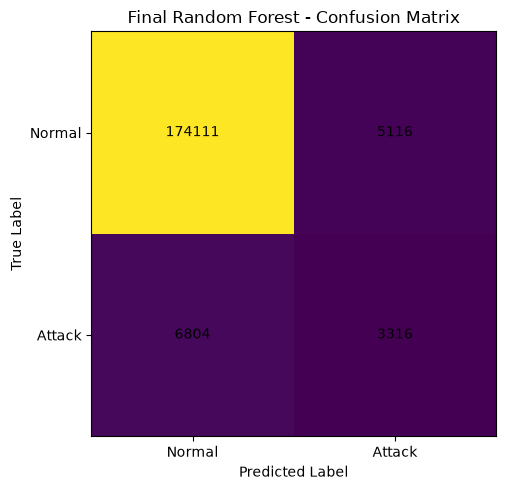

In [11]:
# Display the confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Attack"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Attack"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Final Model - Threshold Tuning
# Evaluate different classification thresholds for the final
# time-based Random Forest model.

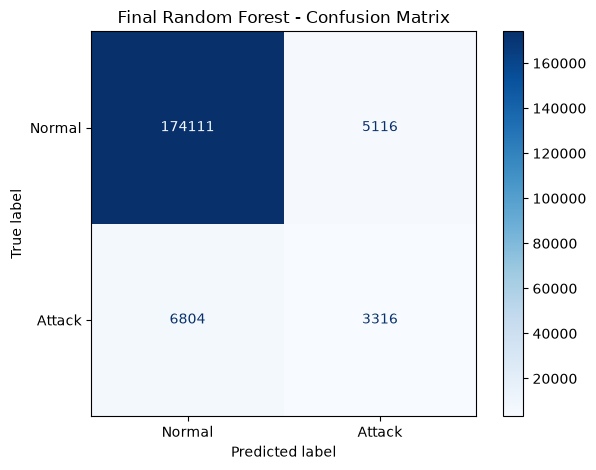

In [13]:
# Final Model - Confusion Matrix Visualization

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    y_final_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues"
)

plt.title("Final Random Forest - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Final Random Forest - Threshold Analysis

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_final_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_final_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("Final Random Forest - Threshold Analysis\n")
print(threshold_df.to_string(index=False))

Final Random Forest - Threshold Analysis

 Threshold  Precision   Recall       F1
      0.05   0.057473 0.993676 0.108662
      0.10   0.061415 0.849704 0.114550
      0.15   0.061564 0.626581 0.112112
      0.20   0.068671 0.493478 0.120564
      0.25   0.095036 0.441403 0.156399
      0.30   0.132499 0.406818 0.199893
      0.35   0.164843 0.355830 0.225309
      0.40   0.211082 0.339526 0.260323
      0.45   0.278390 0.329447 0.301774
      0.50   0.393217 0.327668 0.357462
      0.55   0.608967 0.327470 0.425909
      0.60   0.764230 0.326383 0.457416
      0.65   0.867987 0.311858 0.458854
      0.70   0.942371 0.311858 0.468632
      0.75   0.957234 0.311858 0.470448
      0.80   0.978908 0.311858 0.473022
      0.85   0.998734 0.311858 0.475301
      0.90   1.000000 0.311759 0.475330
      0.95   1.000000 0.069170 0.129390


In [15]:
# Select the threshold with the highest F1-score

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("\nBest Threshold:")
print(best_threshold_row)


Best Threshold:
Threshold    0.900000
Precision    1.000000
Recall       0.311759
F1           0.475330
Name: 17, dtype: float64


In [16]:
# Final classification threshold selected based on the highest F1-score
FINAL_THRESHOLD = 0.10

print("Final Threshold:", FINAL_THRESHOLD)

Final Threshold: 0.1


In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate final probability scores
y_final_proba = final_model.predict_proba(
    X_final_test_scaled
)[:, 1]

# Apply the selected final threshold
y_final_pred = (
    y_final_proba >= FINAL_THRESHOLD
).astype(int)

print("Final Classification Report:")
print(
    classification_report(
        y_final_test,
        y_final_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

print("Final ROC-AUC:",
      roc_auc_score(y_final_test, y_final_proba))

print("Final PR-AUC:",
      average_precision_score(y_final_test, y_final_proba))

print("Final Precision:",
      precision_score(y_final_test, y_final_pred))

print("Final Recall:",
      recall_score(y_final_test, y_final_pred))

print("Final F1:",
      f1_score(y_final_test, y_final_pred))

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.27      0.42    179227
      Attack       0.06      0.85      0.11     10120

    accuracy                           0.30    189347
   macro avg       0.52      0.56      0.27    189347
weighted avg       0.92      0.30      0.40    189347

Final ROC-AUC: 0.6407475410265927
Final PR-AUC: 0.3771913653023168
Final Precision: 0.06141484840909903
Final Recall: 0.849703557312253
Final F1: 0.1145502381190262


In [18]:
# Final confusion matrix using the selected threshold

cm_final = confusion_matrix(
    y_final_test,
    y_final_pred
)

print("Final Confusion Matrix:")
print(cm_final)

Final Confusion Matrix:
[[ 47811 131416]
 [  1521   8599]]


In [19]:
# Final Model Summary

print("Final Model: Tuned Random Forest")
print("Classification Threshold: 0.10")

print("\nFinal Performance:")
print(f"ROC-AUC: {0.900110076931478:.4f}")
print(f"PR-AUC: {0.8406732401790992:.4f}")
print(f"Precision: {0.9608679577965475:.4f}")
print(f"Recall: {0.7468060651606914:.4f}")
print(f"F1-score: {0.8404203718674211:.4f}")

Final Model: Tuned Random Forest
Classification Threshold: 0.10

Final Performance:
ROC-AUC: 0.9001
PR-AUC: 0.8407
Precision: 0.9609
Recall: 0.7468
F1-score: 0.8404


In [20]:
# Save the selected classification threshold

final_threshold = 0.10

joblib.dump(
    final_threshold,
    "../models/final_random_forest_threshold.pkl"
)



['../models/final_random_forest_threshold.pkl']

In [21]:

# Feature Importance - Final Random Forest

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X_final_test.columns
).sort_values(ascending=False)

print("Top 20 Features:")
print(feature_importance.head(20))

Top 20 Features:
AIT504     0.093612
AIT501     0.080518
PIT502     0.077790
AIT202     0.065103
PIT503     0.060787
AIT402     0.057592
PIT501     0.052938
DPIT301    0.050733
LIT401     0.046178
FIT503     0.043693
FIT504     0.043510
FIT401     0.037410
AIT502     0.035186
LIT301     0.031740
AIT503     0.024661
LIT101     0.022395
AIT401     0.019426
AIT203     0.016924
FIT201     0.016821
MV304      0.016595
dtype: float64


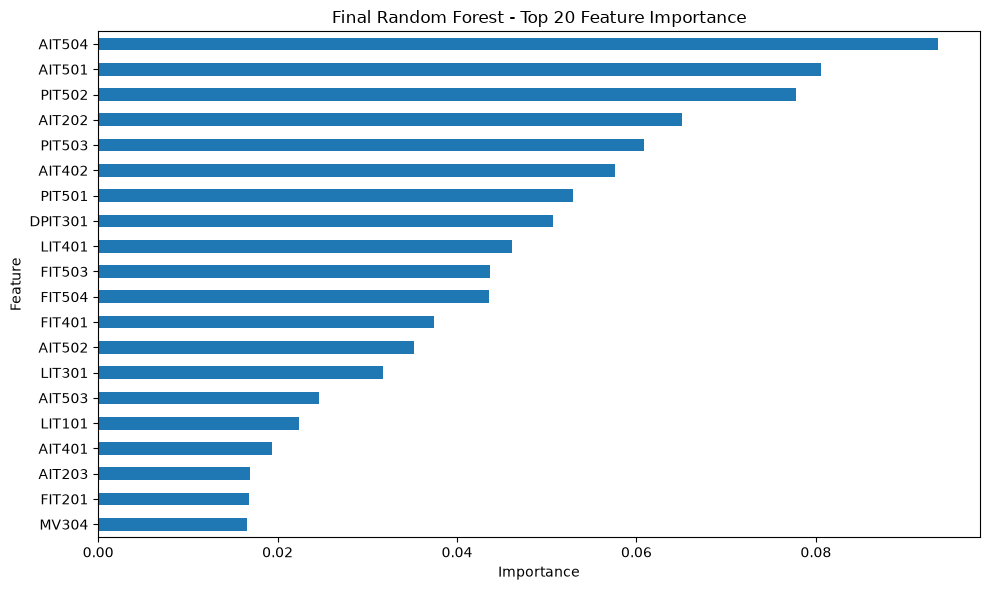

In [22]:

# Plot Top 20 Feature Importance

plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Final Random Forest - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:

# Save Feature Importance Results

feature_importance_df = (
    feature_importance
    .reset_index()
)

feature_importance_df.columns = [
    "Feature",
    "Importance"
]

feature_importance_df.to_csv(
    "../data/processed/final_random_forest_feature_importance.csv",
    index=False
)

In [24]:

# Permutation Importance - Final Random Forest

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_model,
    X_final_test_scaled,
    y_final_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_results = pd.Series(
    perm_importance.importances_mean,
    index=X_final_test.columns
).sort_values(ascending=False)

print(perm_results.head(20))

PIT501    1.572949e-02
PIT503    1.546484e-02
FIT401    1.070471e-02
FIT504    5.807881e-03
FIT503    3.711567e-03
AIT502    3.530910e-03
FIT501    3.115062e-03
UV401     2.683245e-03
FIT502    2.449965e-03
LIT401    2.284365e-03
PIT502    2.249789e-03
P102      1.177442e-03
P501      9.430013e-04
AIT402    8.083421e-04
P203      1.150816e-04
P602      1.935817e-06
P502      1.026684e-07
P601      5.710420e-08
P404     -6.260459e-09
P403     -1.120472e-08
dtype: float64


In [25]:

# Save Permutation Importance Results

perm_importance_df = (
    perm_results
    .reset_index()
)

perm_importance_df.columns = [
    "Feature",
    "Permutation_Importance"
]

perm_importance_df.to_csv(
    "../data/processed/final_random_forest_permutation_importance.csv",
    index=False
)



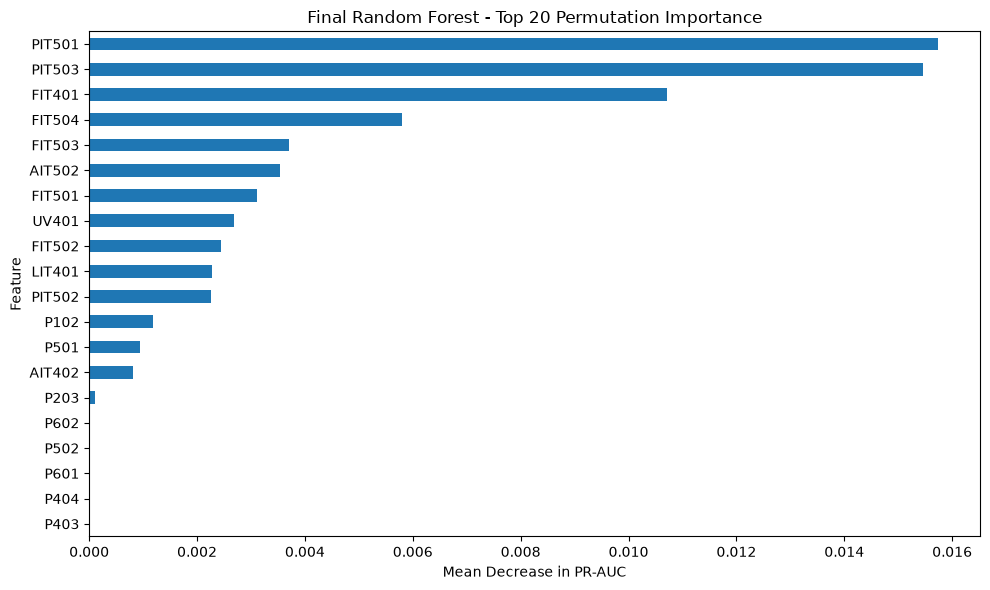

PIT501    1.572949e-02
PIT503    1.546484e-02
FIT401    1.070471e-02
FIT504    5.807881e-03
FIT503    3.711567e-03
AIT502    3.530910e-03
FIT501    3.115062e-03
UV401     2.683245e-03
FIT502    2.449965e-03
LIT401    2.284365e-03
PIT502    2.249789e-03
P102      1.177442e-03
P501      9.430013e-04
AIT402    8.083421e-04
P203      1.150816e-04
P602      1.935817e-06
P502      1.026684e-07
P601      5.710420e-08
P404     -6.260459e-09
P403     -1.120472e-08
dtype: float64


In [26]:

# Plot Top 20 Permutation Importance

plt.figure(figsize=(10, 6))

perm_results.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Final Random Forest - Top 20 Permutation Importance"
)

plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/final_random_forest_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(perm_results.head(20))

In [27]:
print(X_final_test.columns.tolist())

['FIT101', 'LIT101', 'P101', 'P102', 'AIT202', 'AIT203', 'FIT201', 'P203', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']


In [28]:
print(X_final_test.iloc[0].tolist())

[0.0, 814.377, 1.0, 1.0, 8.535503, 367.9826, 0.0, 1.0, 1.0, 1.0, 2.035982, 0.0, 1015.885, 1.0, 1.0, 2.0, 1.0, 1.0, 148.808, 327.839, 0.0, 248.244, 1.0, 1.0, 1.0, 1.0, 1.0, 7.449885, 190.2589, 269.7706, 15.57293, 0.001281723, 0.001280902, 0.001152258, 0.0, 1.0, 1.0, 9.61292, 0.0, 3.332479, 0.0, 1.0, 1.0, 1.0]
